### Install & Import Libraries

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print('All libraries imported successfully!')

All libraries imported successfully!


### Load Dataset

In [3]:
df = pd.read_csv('C:\\Users\\parshav\\Downloads\\heart disease prediction\\heart.csv')
print(f'Dataset loaded! Shape: {df.shape}')
df.head()

Dataset loaded! Shape: (918, 11)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


In [4]:
# Rename Columns
df = df.rename(columns={
    'thalch': 'thalach',
    'num'   : 'target'
})

print("Columns fixed:", df.columns.tolist())

Columns fixed: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'target']


### Step 1: Data Understanding

In [5]:
print('Dataset Shape:', df.shape)
print(f'{df.shape[0]} rows, {df.shape[1]} columns')

Dataset Shape: (918, 11)
918 rows, 11 columns


In [6]:
print('Null Values per Column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Null Values per Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
target      0
dtype: int64

Total missing values: 0


In [7]:
print('Basic Statistics:')
df.describe()

Basic Statistics:


,age,trestbps,chol,thalach,oldpeak,target
count,918.000000,918.000000,918.000000,918.000000,918.00000,918.000000
mean,53.510893,132.141612,199.862745,137.689542,0.85512,0.995643
std,9.432617,17.924706,109.154522,25.153455,1.05845,1.142985
min,28.000000,80.000000,0.000000,60.000000,-2.60000,0.000000
25%,47.000000,120.000000,177.250000,120.000000,0.00000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.50000,1.000000
75%,60.000000,140.000000,267.000000,155.750000,1.50000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.20000,4.000000


Target Column Distribution (before conversion):
target
0    410
1    265
2    108
3    107
4     28
Name: count, dtype: int64


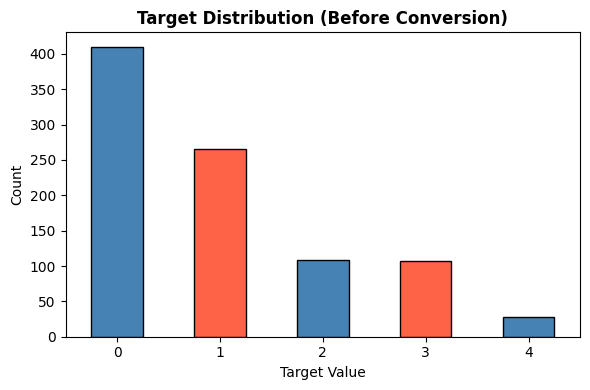

In [8]:
print('Target Column Distribution (before conversion):')
print(df['target'].value_counts())

# Visualize target distribution
fig, ax = plt.subplots(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black', ax=ax)
ax.set_title('Target Distribution (Before Conversion)', fontweight='bold')
ax.set_xlabel('Target Value')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Step 2: Preprocessing

In [9]:
df['target'] = df['target'].apply(lambda x: 0 if x == 0 else 1)

print('Target converted to binary:')
print(df['target'].value_counts())
print('  0 = No Disease')
print('  1 = Disease Present')

Target converted to binary:
target
1    508
0    410
Name: count, dtype: int64
  0 = No Disease
  1 = Disease Present


In [10]:
# Label Encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if categorical_cols:
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])
    print(f'Label Encoding applied to: {categorical_cols}')
else:
    print('No object columns found. All columns are already numeric.')

print('\nSample data after preprocessing:')
df.head()

Label Encoding applied to: ['sex', 'cp', 'restecg']

Sample data after preprocessing:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,target
0,63,1,2,145.0,233.0,True,0,150.0,False,2.3,0
1,67,1,0,160.0,286.0,False,0,108.0,True,1.5,1
2,67,1,0,120.0,229.0,False,0,129.0,True,2.6,1
3,37,1,1,130.0,250.0,False,1,187.0,False,3.5,0
4,41,0,2,130.0,204.0,False,0,172.0,False,1.4,0


In [11]:
# Feature / Target Split
X = df.drop('target', axis=1)
y = df['target']

print(f'Features (X) shape : {X.shape}')
print(f'Target  (y) shape  : {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')

Features (X) shape : (918, 10)
Target  (y) shape  : (918,)

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']


In [12]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standard Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Testing  set size : {X_test.shape[0]} samples')
print('StandardScaler applied.')

Training set size : 734 samples
Testing  set size : 184 samples
StandardScaler applied.


### Step 3: Model Training

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(kernel='rbf', probability=True, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc    = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'predictions': y_pred, 'accuracy': acc}
    print(f'{name:<25} → Accuracy: {acc*100:.2f}%')

Logistic Regression       → Accuracy: 80.98%
Random Forest             → Accuracy: 82.07%
SVM                       → Accuracy: 83.70%


### Step 4: Evaluation

In [14]:
for name, res in results.items():
    print('─'*52)
    print(f'  MODEL : {name}')
    print('─'*52)
    print(f'  Accuracy : {res["accuracy"]*100:.2f}%\n')
    print('  Classification Report:')
    print(classification_report(y_test, res['predictions'],target_names=['No Disease','Disease']))
    print()

────────────────────────────────────────────────────
  MODEL : Logistic Regression
────────────────────────────────────────────────────
  Accuracy : 80.98%

  Classification Report:
              precision    recall  f1-score   support

  No Disease       0.81      0.74      0.78        82
     Disease       0.81      0.86      0.83       102

    accuracy                           0.81       184
   macro avg       0.81      0.80      0.81       184
weighted avg       0.81      0.81      0.81       184


────────────────────────────────────────────────────
  MODEL : Random Forest
────────────────────────────────────────────────────
  Accuracy : 82.07%

  Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.79      0.80        82
     Disease       0.83      0.84      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.8

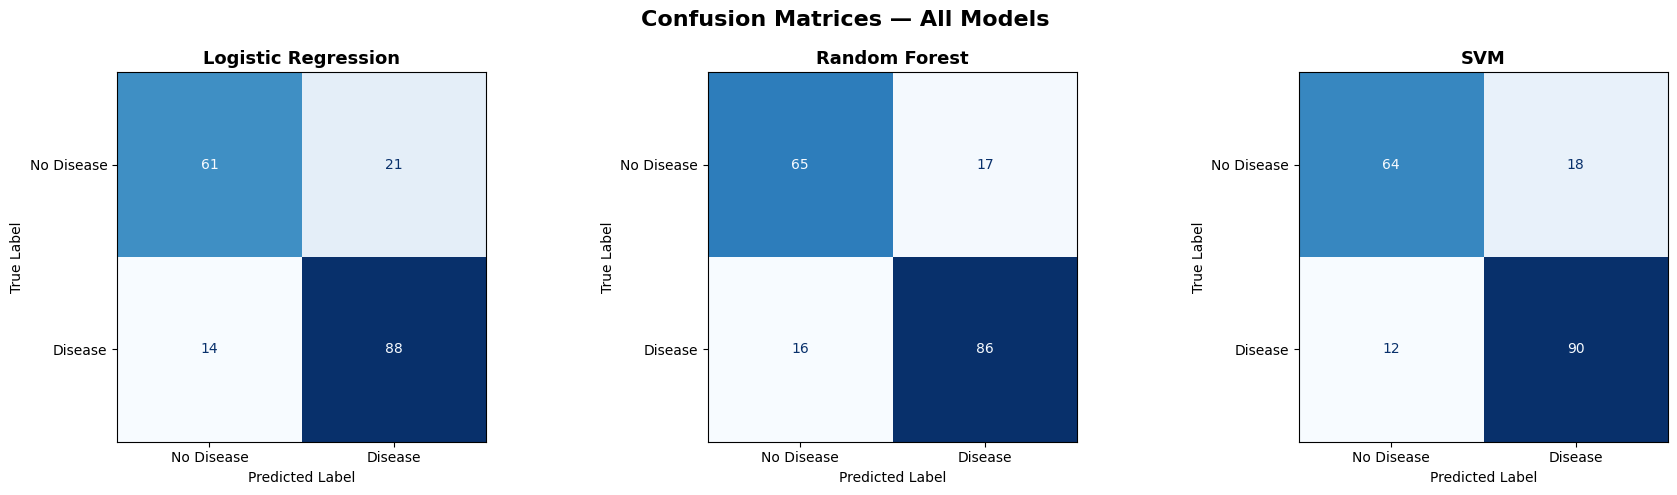

Saved: confusion_matrices.png


In [15]:
# Confusion Matrix for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['predictions'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Disease','Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

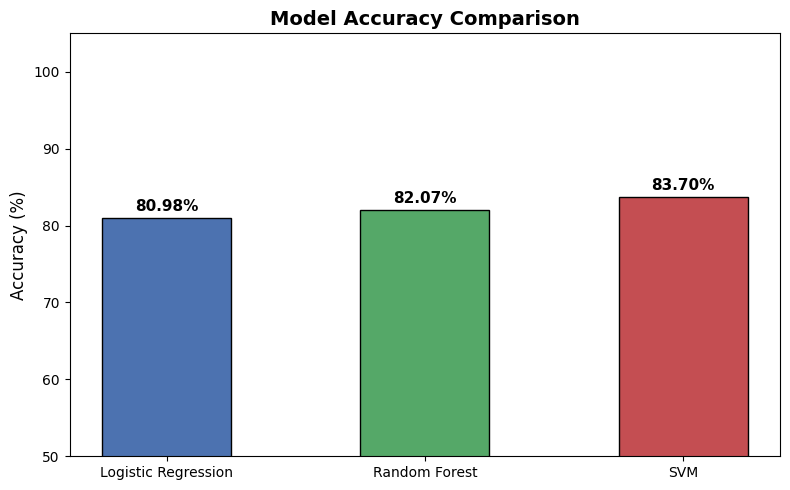

Saved: accuracy_comparison.png


In [16]:
# Accuracy Comparison
fig2, ax2 = plt.subplots(figsize=(8, 5))
names  = list(results.keys())
accs   = [v['accuracy']*100 for v in results.values()]
colors = ['#4C72B0','#55A868','#C44E52']
bars   = ax2.bar(names, accs, color=colors, edgecolor='black', width=0.5)
ax2.set_ylim(50, 105)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: accuracy_comparison.png')

### Step 5: Best Model & Feature Importance

In [17]:
best_name  = max(results, key=lambda k: results[k]['accuracy'])
best_model = results[best_name]['model']
print(f'Best Model : {best_name}  ({results[best_name]["accuracy"]*100:.2f}% accuracy)')

Best Model : SVM  (83.70% accuracy)


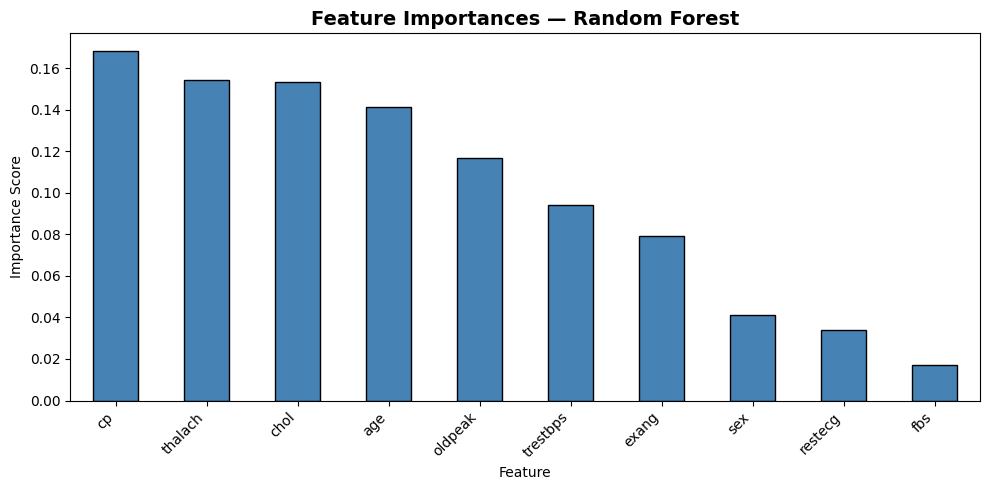


 Top 5 Important Features:
cp         0.168326
thalach    0.154354
chol       0.153440
age        0.141314
oldpeak    0.116936


In [18]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig3, ax3 = plt.subplots(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black', ax=ax3)
ax3.set_title('Feature Importances — Random Forest', fontsize=14, fontweight='bold')
ax3.set_ylabel('Importance Score')
ax3.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Top 5 Important Features:')
print(importances.head(5).to_string())

### Save Best Model (.pkl)

In [19]:
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

print(f'Best model saved  →  best_model.pkl  ({best_name})')
print('Scaler saved      →  scaler.pkl')

Best model saved  →  best_model.pkl  (SVM)
Scaler saved      →  scaler.pkl


### Step 6: Prediction Demo

In [20]:
def predict_heart_disease(input_dict):
    """Load saved model and predict heart disease from patient data."""
    loaded_model  = joblib.load('best_model.pkl')
    loaded_scaler = joblib.load('scaler.pkl')

    input_df      = pd.DataFrame([input_dict])[X.columns]  # ensure column order
    input_scaled  = loaded_scaler.transform(input_df)
    prediction    = loaded_model.predict(input_scaled)[0]
    probability   = loaded_model.predict_proba(input_scaled)[0]

    print('─'*45)
    print('  PREDICTION RESULT')
    print('─'*45)
    for k, v in input_dict.items():
        print(f'  {k:<12}: {v}')
    print('─'*45)
    if prediction == 1:
        print('Result  : DISEASE DETECTED')
    else:
        print('Result  : NO DISEASE')
    print(f'  Probability: No Disease={probability[0]:.2%} | Disease={probability[1]:.2%}')
    print('─'*45)

print('predict_heart_disease() function defined.')

predict_heart_disease() function defined.


In [22]:
# DEMO: Patient 1
patient_1 = {
    'age': 52, 'sex': 1, 'cp': 0, 'trestbps': 125, 'chol': 212,
    'fbs': 0, 'restecg': 1, 'thalach': 168, 'exang': 0,
    'oldpeak': 1.0, 'slope': 2, 'ca': 2, 'thal': 3
}

print('\n Patient 1:')
predict_heart_disease(patient_1)


 Patient 1:
─────────────────────────────────────────────
  PREDICTION RESULT
─────────────────────────────────────────────
  age         : 52
  sex         : 1
  cp          : 0
  trestbps    : 125
  chol        : 212
  fbs         : 0
  restecg     : 1
  thalach     : 168
  exang       : 0
  oldpeak     : 1.0
  slope       : 2
  ca          : 2
  thal        : 3
─────────────────────────────────────────────
Result  : DISEASE DETECTED
  Probability: No Disease=40.87% | Disease=59.13%
─────────────────────────────────────────────


In [ ]:
# DEMO: Patient 2
patient_2 = {
    'age': 63, 'sex': 1, 'cp': 3, 'trestbps': 145, 'chol': 233,
    'fbs': 1, 'restecg': 0, 'thalach': 150, 'exang': 0,
    'oldpeak': 2.3, 'slope': 0, 'ca': 0, 'thal': 1
}

print('\n Patient 2:')
predict_heart_disease(patient_2)


 Patient 2:
─────────────────────────────────────────────
  PREDICTION RESULT
─────────────────────────────────────────────
  age         : 63
  sex         : 1
  cp          : 3
  trestbps    : 145
  chol        : 233
  fbs         : 1
  restecg     : 0
  thalach     : 150
  exang       : 0
  oldpeak     : 2.3
  slope       : 0
  ca          : 0
  thal        : 1
─────────────────────────────────────────────
Result  : NO DISEASE
  Probability: No Disease=67.08% | Disease=32.92%
─────────────────────────────────────────────
